In [93]:
#import required libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

In [95]:
#load the stocks dataset
df = pd.read_csv("C:\\Users\srisa\Downloads\stocks.csv")
df.head()

,date,BA,CAT,DIS,GE,IBM,KO
0,2000-01-03,27.180308,14.984244,23.839401,29.005613,85.155442,17.779754
1,2000-01-04,27.139731,14.790123,25.235618,27.845388,82.263093,17.839810
2,2000-01-05,29.040120,15.347834,26.129196,27.797045,85.155442,18.035783
3,2000-01-06,29.121276,15.908626,25.235618,28.168317,83.687245,18.016818
4,2000-01-07,29.966645,16.426281,24.836699,29.258928,83.320195,19.202135


In [96]:
#data cleaning and preprocessing 
date_columns = X.select_dtypes(include=['object']).columns.tolist()

# Option 1: Drop date columns if they're not needed for modeling
X_numeric = X.drop(columns=date_columns)

# Option 2: Convert dates to numerical features
# X['day_of_week'] = pd.to_datetime(X['2000-01-03']).dt.dayofweek
# X['month'] = pd.to_datetime(X['2000-01-03']).dt.month
# X['year'] = pd.to_datetime(X['2000-01-03']).dt.year
# X_numeric = X.drop(columns=['2000-01-03'])  # Drop original date column

# Now scale only the numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [97]:
#Generator & discriminator
latent_dim = 32
feature_dim = X_train.shape[1]

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, feature_dim)
        )
    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

In [98]:
#Train GAN on Financial Dataset
G = Generator()
D = Discriminator()

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

epochs = 1500
batch_size = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

for epoch in range(epochs):
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_data = X_train_tensor[idx]

    valid = torch.ones(batch_size, 1)
    fake = torch.zeros(batch_size, 1)

    # Train Generator
    z = torch.randn(batch_size, latent_dim)
    gen_data = G(z)
    g_loss = criterion(D(gen_data), valid)

    optimizer_G.zero_grad()
    g_loss.backward()
    optimizer_G.step()

    # Train Discriminator
    real_loss = criterion(D(real_data), valid)
    fake_loss = criterion(D(gen_data.detach()), fake)
    d_loss = (real_loss + fake_loss) / 2

    optimizer_D.zero_grad()
    d_loss.backward()
    optimizer_D.step()

    if epoch % 300 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


Epoch 0 | D Loss: 0.7210 | G Loss: 0.6139
Epoch 300 | D Loss: 0.6142 | G Loss: 0.7144
Epoch 600 | D Loss: 0.5777 | G Loss: 0.8623
Epoch 900 | D Loss: 0.7324 | G Loss: 0.5978
Epoch 1200 | D Loss: 0.6891 | G Loss: 0.9192


In [99]:
#Generate Synthetic Financial Data
n_synthetic = int(0.5 * len(X_train))

z = torch.randn(n_synthetic, latent_dim)
synthetic_X = G(z).detach().numpy()

# Preserve original fraud ratio
synthetic_y = np.random.choice(y_train, n_synthetic)

# Augmented dataset
X_aug = np.vstack([X_train, synthetic_X])
y_aug = np.hstack([y_train, synthetic_y])


In [102]:
#Fraud Detection Model (Random Forest)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_aug, y_aug)

y_pred = rf.predict(X_test)

print("Regression Results")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


y_aug = y_aug.astype(int)
y_test = y_test.astype(int)


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
rf = RandomForestClassifier(
     n_estimators=200,
     random_state=42,
     class_weight="balanced"
)
 
rf.fit(X_aug, y_aug)
 
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
 
print("Fraud Detection Results")
print(classification_report(y_test, y_pred))


Regression Results
Mean Squared Error: 0.1284803376906318
R² Score: 0.9987697715614895
Fraud Detection Results
              precision    recall  f1-score   support

          12       1.00      1.00      1.00         1
          13       1.00      0.97      0.99        35
          14       0.99      1.00      1.00       101
          15       1.00      0.99      1.00       108
          16       0.99      1.00      0.99        73
          17       1.00      1.00      1.00        61
          18       0.97      1.00      0.99        39
          19       0.98      0.96      0.97        46
          20       0.95      0.95      0.95        20
          21       1.00      1.00      1.00        43
          22       1.00      1.00      1.00        23
          23       0.89      1.00      0.94         8
          24       1.00      0.75      0.86         4
          25       1.00      0.91      0.95        11
          26       0.94      0.89      0.91        18
          27       0.88 

In [109]:
# Convert synthetic data to DataFrame
synthetic_df = pd.DataFrame(
    synthetic_X,
    columns=X.columns  
)

synthetic_df.head()

,BA,CAT,DIS,GE,IBM,KO
0,1.123134,1.986117,1.806531,0.408897,0.602353,0.517801
1,0.298565,0.197184,0.406745,-0.471224,0.022064,-0.123638
2,-0.205576,-0.410141,-0.210073,-0.570212,-0.723095,-0.675174
3,-0.764779,-1.560009,-1.399751,-0.850199,-1.440540,-1.416494
4,-0.616911,-0.849838,-0.876013,0.190736,-1.365819,-1.127809


In [105]:
#Add Fraud Labels to Synthetic Data
synthetic_real = scaler.inverse_transform(synthetic_X)

synthetic_df_real = pd.DataFrame(
    synthetic_real,
    columns=X.columns
)

synthetic_df_real["label"] = synthetic_y
synthetic_df_real.head()

,BA,CAT,DIS,GE,IBM,KO,label
0,138.875351,116.612358,100.835693,23.536234,132.471863,30.373878,40.108624
1,91.651932,60.563492,57.132389,18.518713,108.827072,23.787294,14.681578
2,62.779533,41.535480,37.874458,17.954390,78.464378,18.123869,14.567740
3,30.753721,5.509104,0.731048,16.358200,49.230946,10.511648,25.778265
4,39.222176,27.759382,17.082876,22.292509,52.275570,13.476003,34.829411


In [110]:
#Inverse Transform ( Human-Readable Values)
synthetic_df["label"] = synthetic_y

synthetic_df.head()

,BA,CAT,DIS,GE,IBM,KO,label
0,1.123134,1.986117,1.806531,0.408897,0.602353,0.517801,40.108624
1,0.298565,0.197184,0.406745,-0.471224,0.022064,-0.123638,14.681578
2,-0.205576,-0.410141,-0.210073,-0.570212,-0.723095,-0.675174,14.567740
3,-0.764779,-1.560009,-1.399751,-0.850199,-1.440540,-1.416494,25.778265
4,-0.616911,-0.849838,-0.876013,0.190736,-1.365819,-1.127809,34.829411


In [111]:
#Display Entire Synthetic Dataset
pd.set_option("display.max_rows", 100)
synthetic_df_real

,BA,CAT,DIS,GE,IBM,KO,label
0,138.875351,116.612358,100.835693,23.536234,132.471863,30.373878,40.108624
1,91.651932,60.563492,57.132389,18.518713,108.827072,23.787294,14.681578
2,62.779533,41.535480,37.874458,17.954390,78.464378,18.123869,14.567740
3,30.753721,5.509104,0.731048,16.358200,49.230946,10.511648,25.778265
4,39.222176,27.759382,17.082876,22.292509,52.275570,13.476003,34.829411
...,...,...,...,...,...,...,...
1829,81.299522,58.950699,48.307541,22.671854,91.777298,22.569466,16.950008
1830,61.242081,44.643391,37.474483,20.670416,76.389183,18.460501,19.602785
1831,108.668991,78.452156,69.489838,20.041491,122.866035,27.482159,27.534490
1832,136.420380,97.628029,92.875000,18.092348,133.601257,32.145096,33.535928


In [112]:
#Compare Real vs Synthetic Statistics
comparison = pd.DataFrame({
    "Real Mean": X.mean(),
    "Synthetic Mean": synthetic_df_real.drop("label", axis=1).mean(),
    "Real Std": X.std(),
    "Synthetic Std": synthetic_df_real.drop("label", axis=1).std()
})

comparison

,Real Mean,Synthetic Mean,Real Std,Synthetic Std
BA,74.552965,89.944221,57.276688,58.271454
CAT,54.385553,64.186638,31.334303,44.787045
DIS,44.433235,55.891563,31.224815,42.248734
GE,21.205135,19.874275,5.701561,2.487662
IBM,107.928029,97.679901,40.751032,45.341633
KO,25.056862,22.541149,10.269578,10.829322


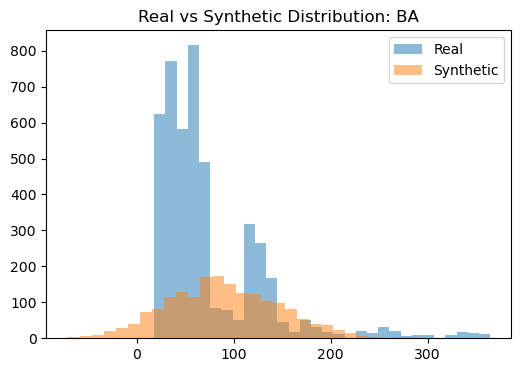

In [108]:
#Visual Comparison
feature = X.columns[0]  # choose any financial feature

plt.figure(figsize=(6,4))
plt.hist(X[feature], bins=30, alpha=0.5, label="Real")
plt.hist(synthetic_df_real[feature], bins=30, alpha=0.5, label="Synthetic")
plt.legend()
plt.title(f"Real vs Synthetic Distribution: {feature}")
plt.show()